In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:

# ====================== 1. LOAD DATA ======================
df = pd.read_csv(r"C:\Users\Acer\Desktop\ML projects\ecommerce_linear_regression_dataset (2).csv")

print("Original shape:", df.shape)
print(df.head())

Original shape: (30, 7)
   Customer_ID  Age Monthly_Spend  Items_Purchased  Website_Visits  \
0          101   25          1200                2             5.0   
1          102   32          2500                4            12.0   
2          103   28          1800                3             8.0   
3          104   45          4200                6            20.0   
4          105   23           900                1             3.0   

   Premium_Member  Annual_Spend  
0             0.0        4500.0  
1             1.0        8200.0  
2             0.0        6200.0  
3             1.0       12500.0  
4             0.0        3200.0  


In [21]:
# ====================== 2. IMPROVED DATA CLEANING ======================
# Convert all relevant columns to numeric (force errors to NaN)
numeric_cols = ['Age', 'Monthly_Spend', 'Items_Purchased', 
                'Website_Visits', 'Premium_Member', 'Annual_Spend']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')



In [22]:
# Drop rows where target (Annual_Spend) is missing
df = df.dropna(subset=['Annual_Spend']).reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (29, 7)


In [23]:
# Fill remaining missing values with median
for col in numeric_cols:
    if df[col].isna().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in {col} with median: {median_val}")

# Remove extreme outlier
df = df[df['Monthly_Spend'] < 10000].reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("\nAny NaNs left?", df[numeric_cols].isna().sum().sum())

Filled missing values in Monthly_Spend with median: 2700.0
Filled missing values in Website_Visits with median: 12.0
Filled missing values in Premium_Member with median: 0.5
Cleaned shape: (28, 7)

Any NaNs left? 0


In [24]:

# ====================== 3. FEATURES & TARGET ======================
X = df[['Age', 'Monthly_Spend', 'Items_Purchased', 
        'Website_Visits', 'Premium_Member']]
y = df['Annual_Spend']

In [25]:
# ====================== 4. K-FOLD CROSS VALIDATION ======================
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []
r2_scores = []

print("\n=== 5-Fold Cross Validation ===")
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)           # ← This line was failing before
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    r2_scores.append(r2)
    
    print(f"Fold {fold}: MSE = {mse:,.0f} | R² = {r2:.4f}")

print("\n=== Final Results ===")
print(f"Mean MSE : {np.mean(mse_scores):,.0f} (± {np.std(mse_scores):,.0f})")
print(f"Mean R²  : {np.mean(r2_scores):.4f}")


=== 5-Fold Cross Validation ===
Fold 1: MSE = 51,189 | R² = 0.9909
Fold 2: MSE = 32,163 | R² = 0.9946
Fold 3: MSE = 51,976 | R² = 0.9951
Fold 4: MSE = 56,191 | R² = 0.9955
Fold 5: MSE = 35,629 | R² = 0.9972

=== Final Results ===
Mean MSE : 45,430 (± 9,632)
Mean R²  : 0.9947


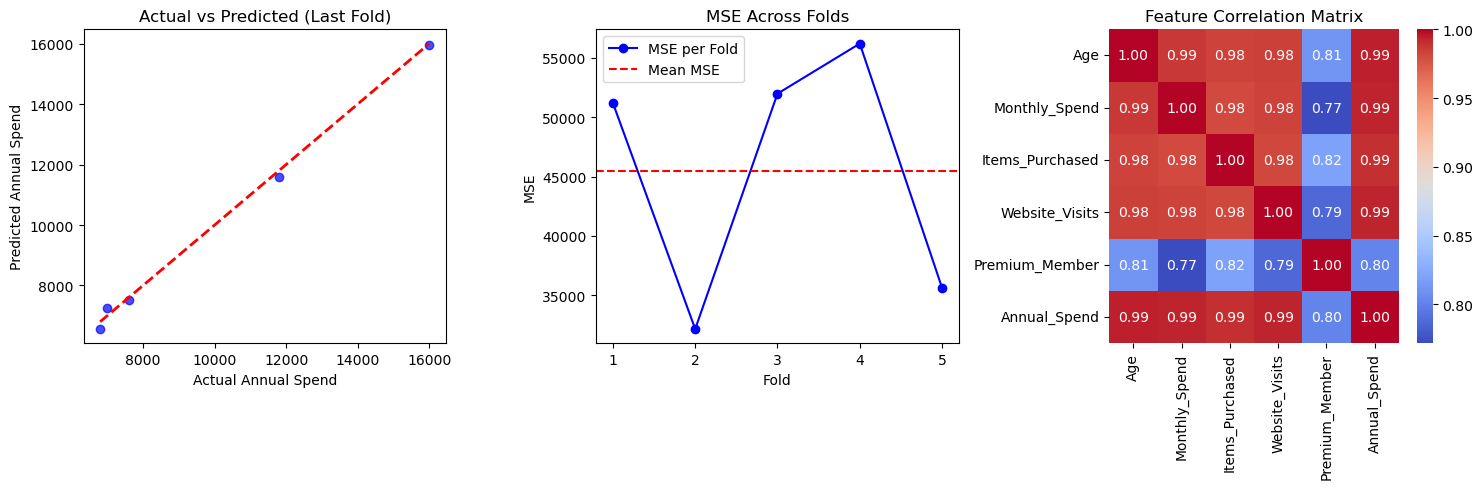

In [26]:
# ====================== 5. VISUALIZATIONS ======================
plt.figure(figsize=(15, 5))

# 1. Actual vs Predicted (last fold)
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Annual Spend')
plt.ylabel('Predicted Annual Spend')
plt.title('Actual vs Predicted (Last Fold)')

# 2. MSE per Fold
plt.subplot(1, 3, 2)
plt.plot(range(1, 6), mse_scores, 'bo-', label='MSE per Fold')
plt.axhline(np.mean(mse_scores), color='red', linestyle='--', label='Mean MSE')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('MSE Across Folds')
plt.legend()

# 3. Correlation Heatmap
plt.subplot(1, 3, 3)
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()